In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
np.random.seed(42)
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import itertools

In [4]:
val = pd.read_csv("sales_train_validation.csv")
eva = pd.read_csv("sales_train_evaluation.csv")

The baseline models implemented are local univariate models, meaning each model can only learn patterns from the historical observations of a single time series with one feature varying over time. These models can not learn shared or global patterns across multiple product series simultaneously.

No feature engineering was used due to this univariate nature.

A total of 30490 records are present representing unit sales of each product aggregated for each store. Due to the local modeling nature, training 30490 separate models would be required to generate 28-day forecasts for all series.

To keep the analysis computationally manageable while still evaluating model behaviour across different retail demand patterns, three representative series were selected:
- a relatively stable series
- a sporadic series containing a large number of zero sale values
- a seasonal series exhibiting repeating temporal patterns

These series were selected manually through exploratory inspection of the dataset using a batch-wise iterative approach with loops and visual analysis.

For the stable series, a series whose values remained relatively close to its mean over time with comparatively lower fluctuations was selected.

The sporadic series was selected by identifying a series containing a high proportion of zero sales observations representing intermittent demand behaviour commonly seen in retail forecasting.

For the seasonal series, time series plots were used to visually identify strong seasonal patterns. ACF and PACF plots of these original (non-stationary) series were further used to confirm presence of seasonality by observing seasonal peaks and lag structures.

'sales_train_validation' dataset contains sales observations from d_1 to d_1913, while 'sales_train_evaluation' extends this to d_1941. 'sales_train_validation' is used to train the models so that the forecasted data of 28 days ahead can be evaluated against actual sales data available in 'sales_train_evaluation' i.e. d_1914 - d_1941

sales_train_validation : d_1 - d_1913

sales_train_evaluation : d_1 - d_1941

forecast horizon : d_1914 - d_1941

In [5]:
STABLE_IDX = 26842  # FOODS_3_226_WI_2 - relatively stable demand
SPORADIC_IDX = 5654  # FOODS_3_381_CA_2 - high proportion of zero sales
SEASONAL_IDX = 20770  # FOODS_3_252_TX_3 - strong weekly seasonality

In [6]:
METADATA_COLS = 6
FORECAST_HORIZON = 28

In [7]:
train_stable = val.iloc[STABLE_IDX, METADATA_COLS:]
train_sporadic = val.iloc[SPORADIC_IDX, METADATA_COLS:]
train_seasonal = val.iloc[SEASONAL_IDX, METADATA_COLS:]

# print(train_stable.dtype) -> object
train_stable = train_stable.astype(float)
train_sporadic = train_sporadic.astype(float)
train_seasonal = train_seasonal.astype(float)

train_stable.index = range(len(train_stable))
train_sporadic.index = range(len(train_sporadic))
train_seasonal.index = range(len(train_seasonal))

In [8]:
test_stable = eva.iloc[STABLE_IDX, -FORECAST_HORIZON:]
test_sporadic = eva.iloc[SPORADIC_IDX, -FORECAST_HORIZON:]
test_seasonal = eva.iloc[SEASONAL_IDX, -FORECAST_HORIZON:]

test_stable = test_stable.astype(float)
test_sporadic = test_sporadic.astype(float)
test_seasonal = test_seasonal.astype(float)

test_stable.index = range(len(train_stable), len(train_stable) + len(test_stable))
test_sporadic.index = range(len(train_sporadic), len(train_sporadic) + len(test_sporadic))
test_seasonal.index = range(len(train_seasonal), len(train_seasonal) + len(test_seasonal))

# Naive forecast

In [9]:
def evaluate_forecast(train, test, forecast):
  plt.figure(figsize=(20, 5))
  train.plot(label='train')
  test.plot(label='test')
  forecast.plot(label='forecast')
  plt.legend()
  plt.show()

  mae = mean_absolute_error(test, forecast)
  rmse = np.sqrt(mean_squared_error(test, forecast))
  print("MAE:", mae)
  print("RMSE:", rmse)
  return mae, rmse

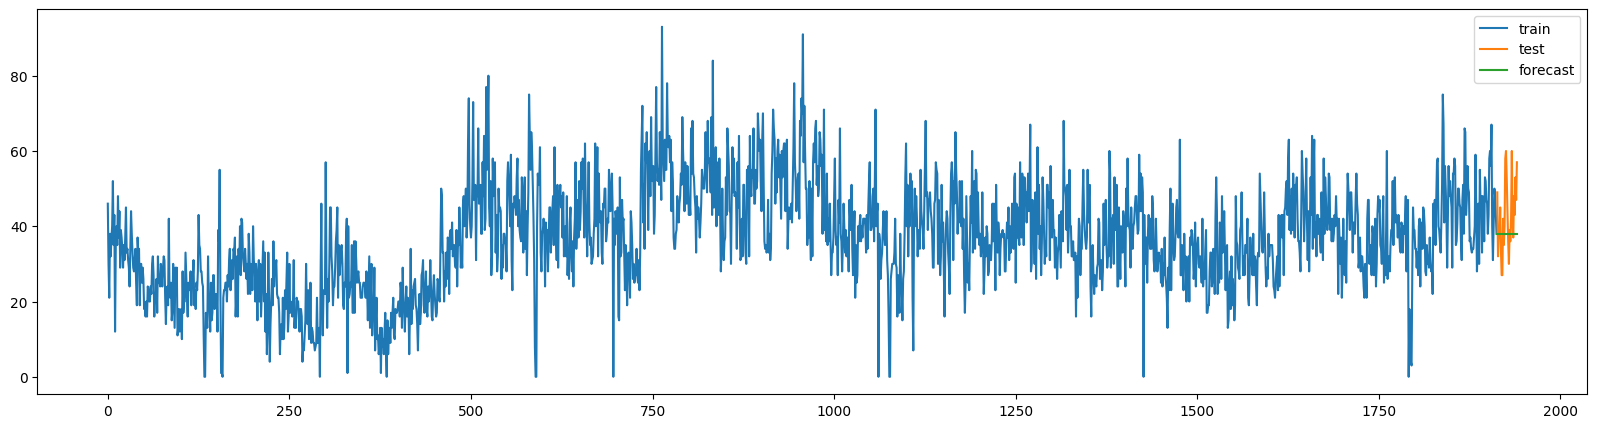

MAE: 8.035714285714286
RMSE: 10.387148653160653


In [10]:
forecast_stable_naive = pd.Series(train_stable.iloc[-1], index=test_stable.index)

mae_stable_naive, rmse_stable_naive = evaluate_forecast(train_stable, test_stable, forecast_stable_naive)

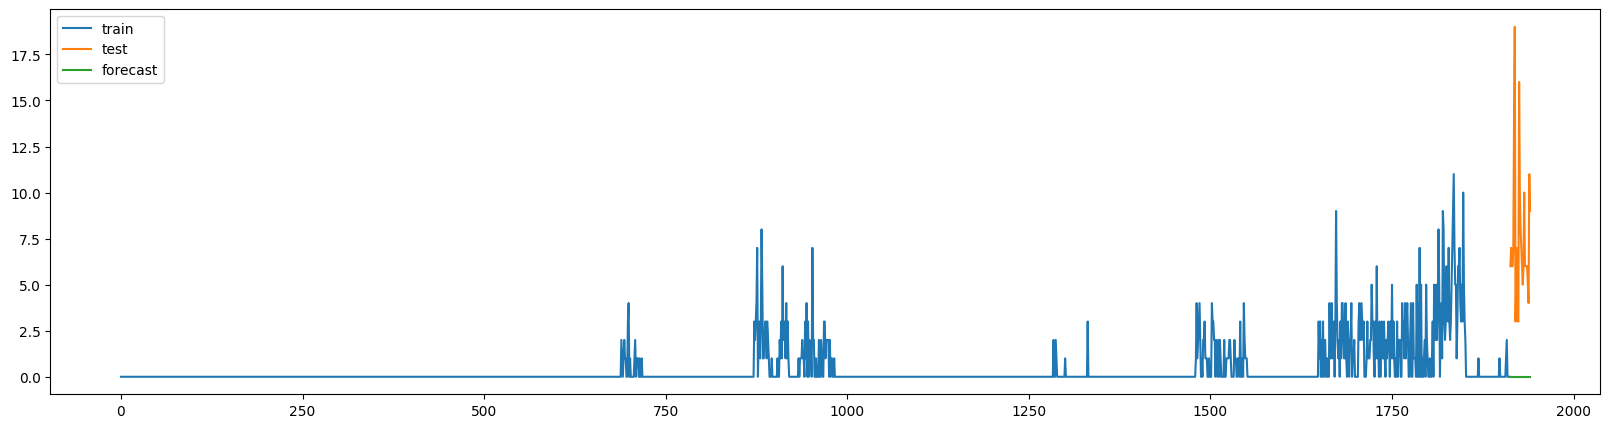

MAE: 7.392857142857143
RMSE: 8.274314818417638


In [11]:
forecast_sporadic_naive = pd.Series(train_sporadic.iloc[-1], index=test_sporadic.index)

mae_sporadic_naive, rmse_sporadic_naive = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_naive)

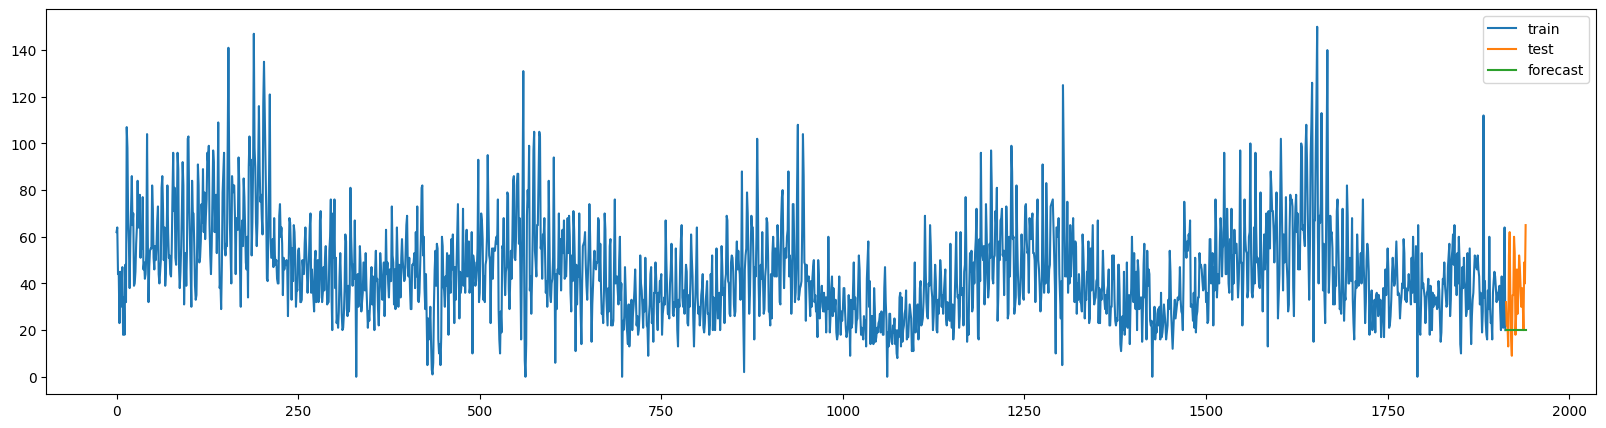

MAE: 17.785714285714285
RMSE: 21.88933203966848


In [12]:
forecast_seasonal_naive = pd.Series(train_seasonal.iloc[-1], index=test_seasonal.index)

mae_seasonal_naive, rmse_seasonal_naive = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_naive)

# Seasonal naive

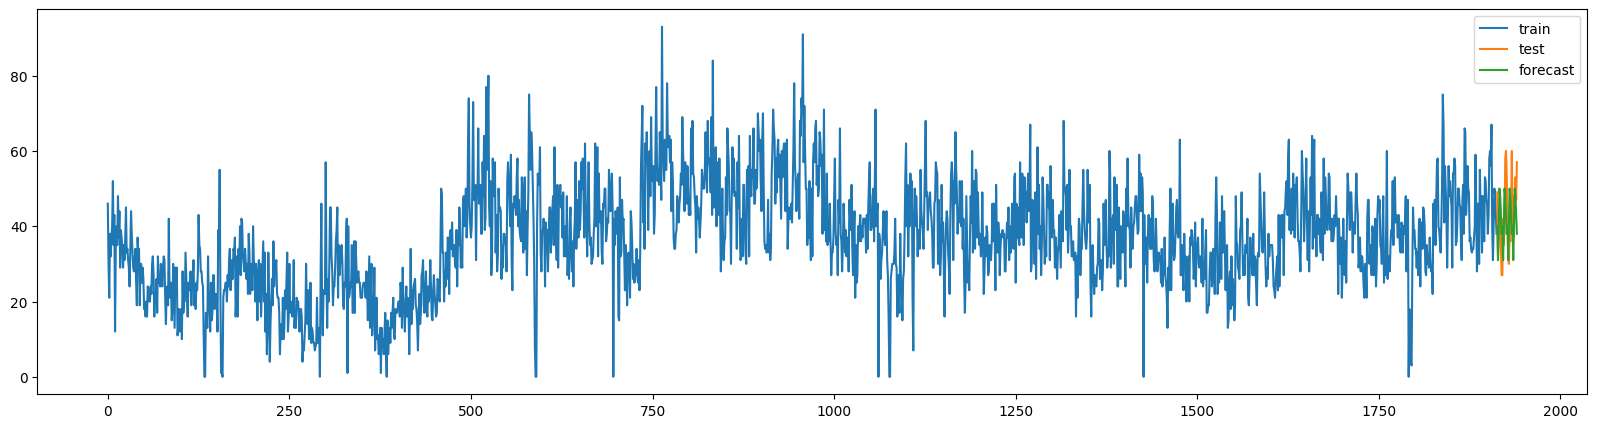

MAE: 8.75
RMSE: 10.248693296499525


In [13]:
tiled_stable_seasonal_naive = np.tile(train_stable.iloc[-7:].values, (len(test_stable) // 7) + 1)
forecast_stable_seasonal_naive = pd.Series(tiled_stable_seasonal_naive[:len(test_stable)], index=test_stable.index)
# generate more than req values if len not completely div by 7 then trim to required length

mae_stable_seasonal_naive, rmse_stable_seasonal_naive = evaluate_forecast(train_stable, test_stable, forecast_stable_seasonal_naive)

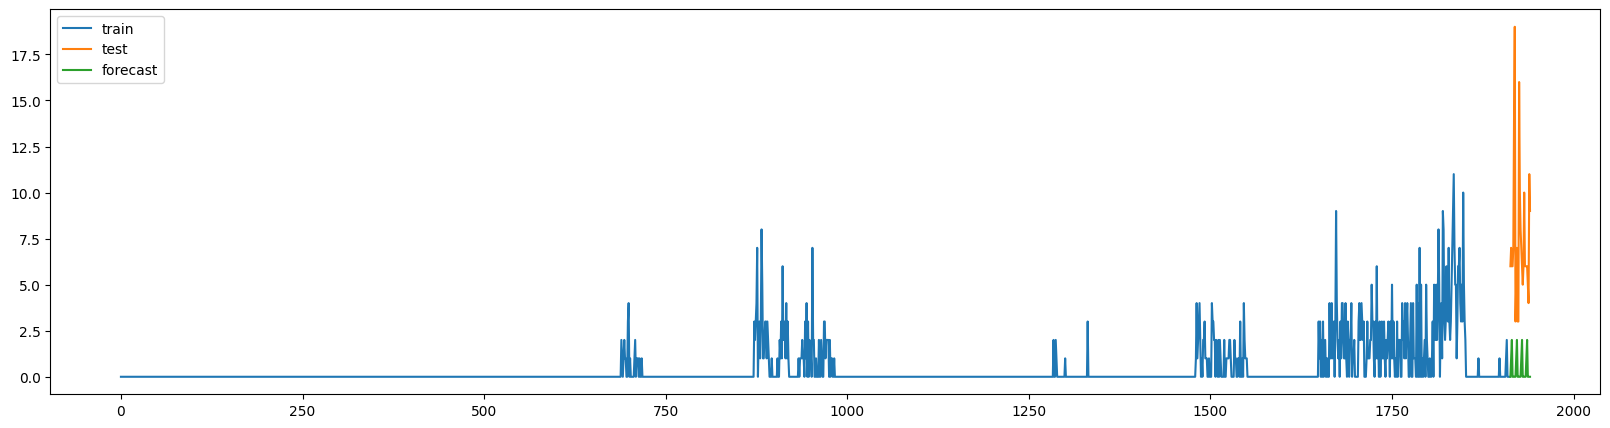

MAE: 6.964285714285714
RMSE: 7.988831489737944


In [14]:
tiled_sporadic_seasonal_naive = np.tile(train_sporadic.iloc[-7:].values, (len(test_sporadic) // 7) + 1)
forecast_sporadic_seasonal_naive = pd.Series(tiled_sporadic_seasonal_naive[:len(test_sporadic)], index=test_sporadic.index)

mae_sporadic_seasonal_naive, rmse_sporadic_seasonal_naive = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_seasonal_naive)

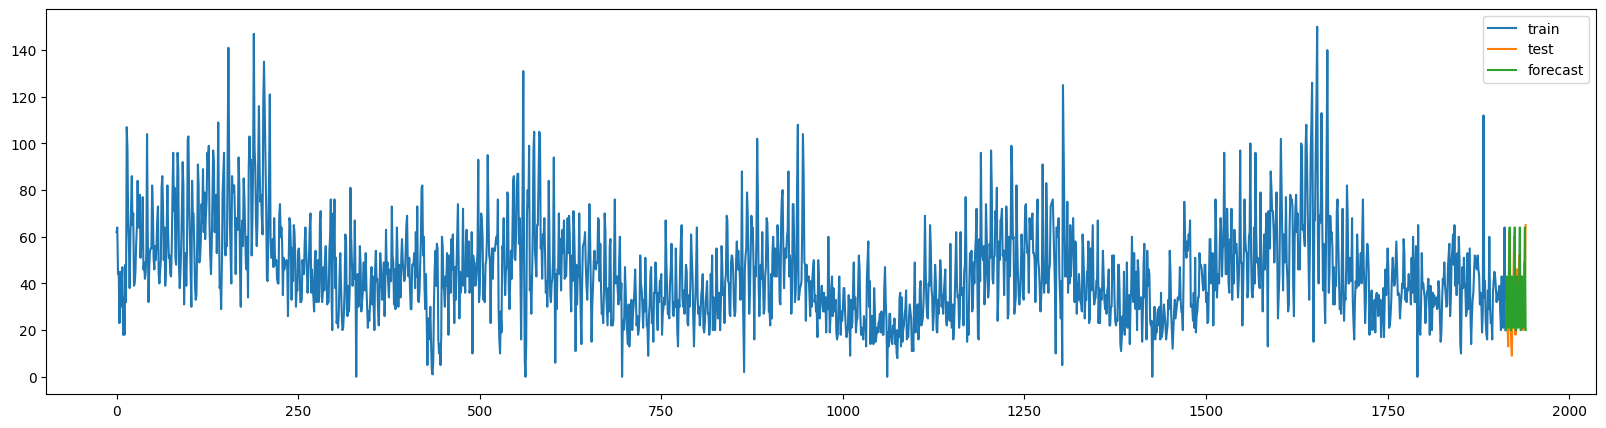

MAE: 12.785714285714286
RMSE: 16.250274722952486


In [15]:
tiled_seasonal_seasonal_naive = np.tile(train_seasonal.iloc[-7:].values, (len(test_seasonal) // 7) + 1)
forecast_seasonal_seasonal_naive = pd.Series(tiled_seasonal_seasonal_naive[:len(test_seasonal)], index=test_seasonal.index)

mae_seasonal_seasonal_naive, rmse_seasonal_seasonal_naive = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_seasonal_naive)

# Simple moving average

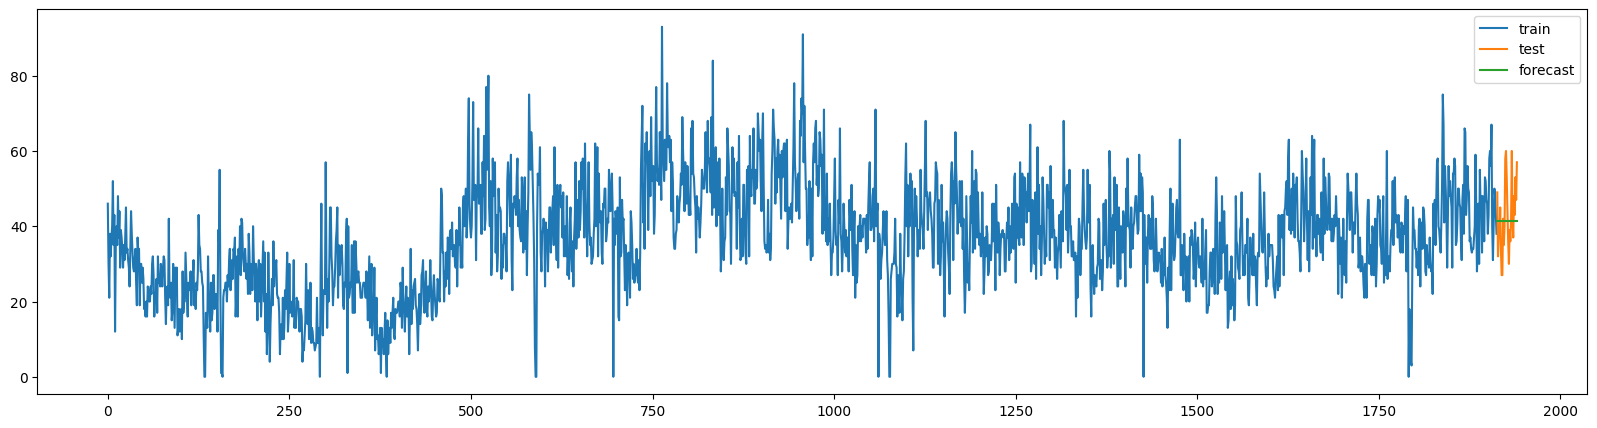

MAE: 7.5765306122448965
RMSE: 9.409884078316106


In [16]:
forecast_stable_sma = pd.Series(train_stable[-7:].mean(), index=test_stable.index)

mae_stable_sma, rmse_stable_sma = evaluate_forecast(train_stable, test_stable, forecast_stable_sma)

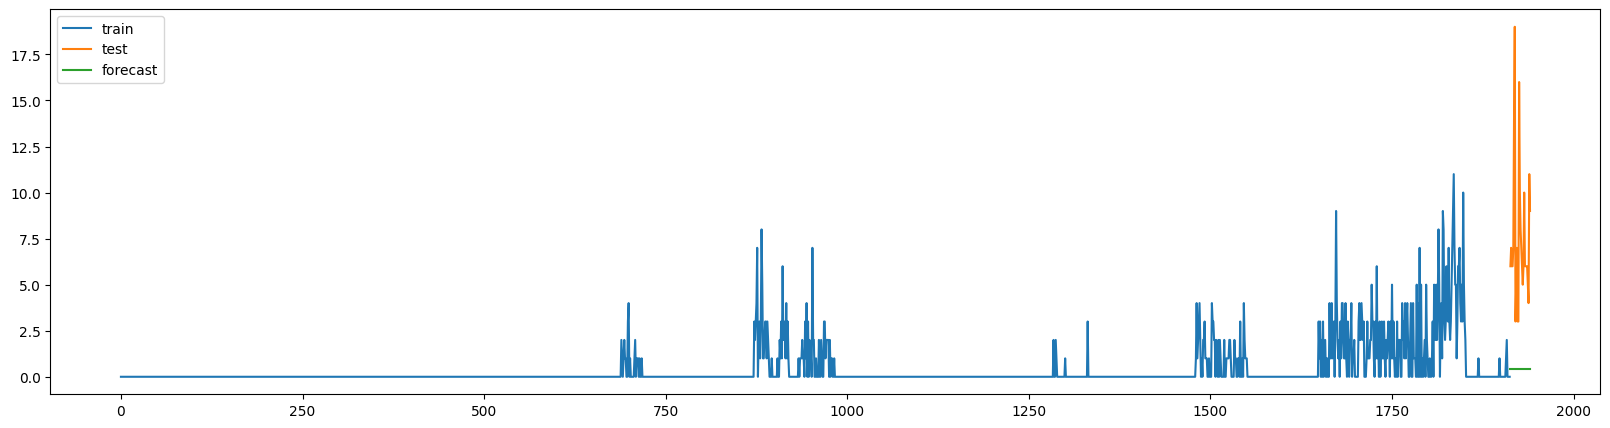

MAE: 6.964285714285716
RMSE: 7.893745909883084


In [17]:
forecast_sporadic_sma = pd.Series(train_sporadic[-7:].mean(), index=test_sporadic.index)

mae_sporadic_sma, rmse_sporadic_sma = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_sma)

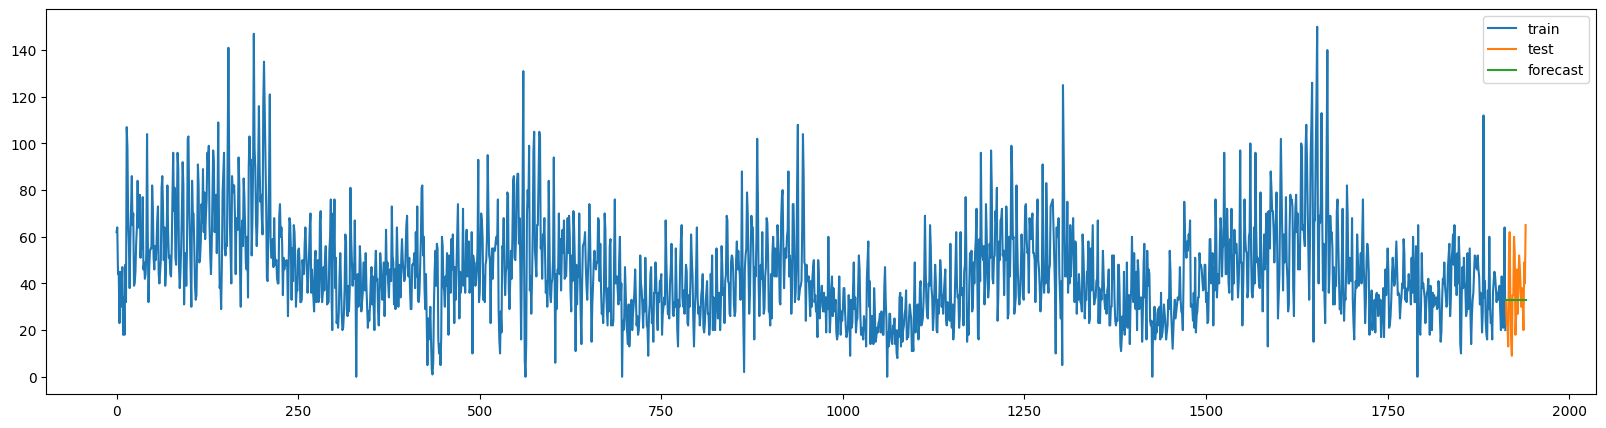

MAE: 12.255102040816325
RMSE: 15.235565266165604


In [18]:
forecast_seasonal_sma = pd.Series(train_seasonal[-7:].mean(), index=test_seasonal.index)

mae_seasonal_sma, rmse_seasonal_sma = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_sma)

# Recursive moving average

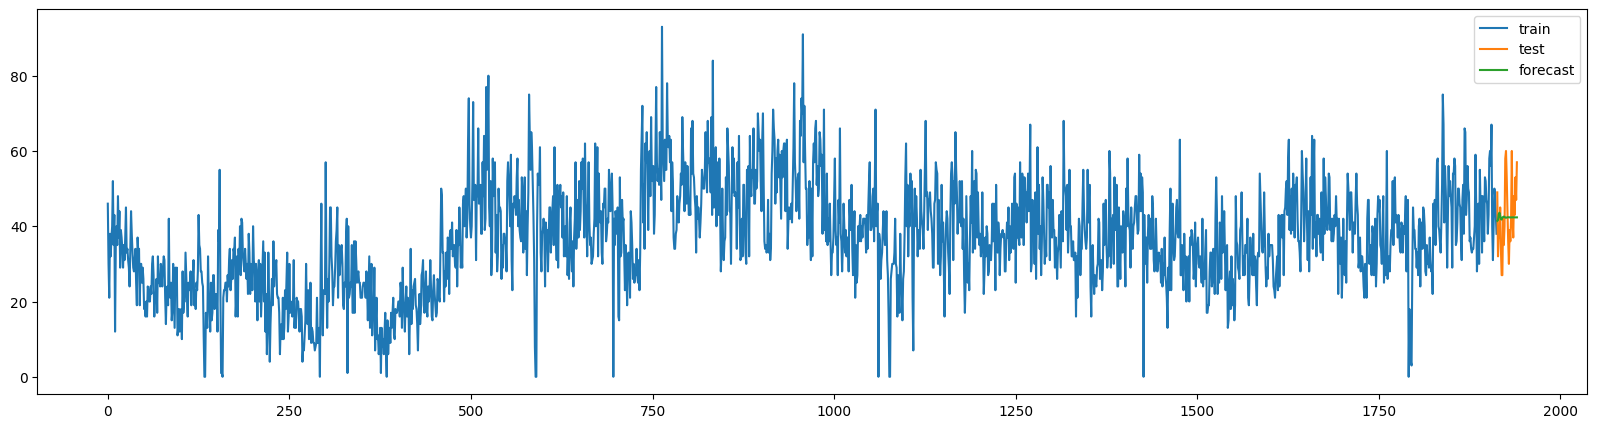

MAE: 7.639608117619273
RMSE: 9.354353493141957


In [19]:
forecast_stable_rma = pd.Series(index=test_stable.index, dtype=float)
window_stable = list(train_stable[-7:])  # list for efficient appending vs growing a DataFrame
for i in range(len(test_stable)):
    forecast_stable_rma.iloc[i] = np.mean(window_stable[-7:])
    window_stable.append(forecast_stable_rma.iloc[i])

mae_stable_rma, rmse_stable_rma = evaluate_forecast(train_stable, test_stable, forecast_stable_rma)

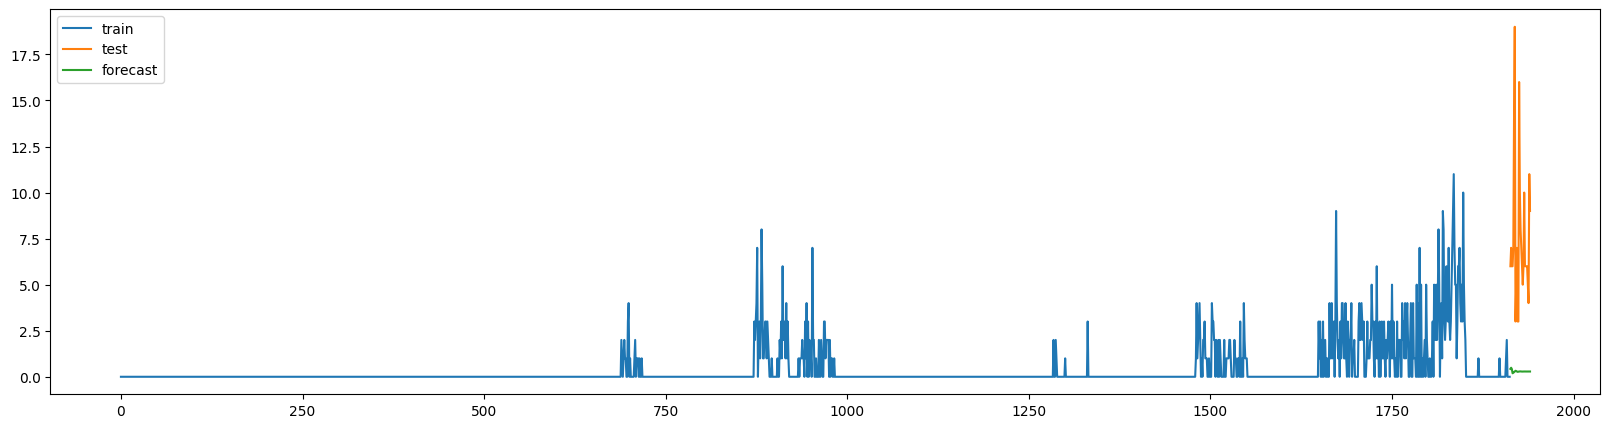

MAE: 7.09565896991888
RMSE: 8.012947820557596


In [20]:
forecast_sporadic_rma = pd.Series(index=test_sporadic.index, dtype=float)
window_sporadic = list(train_sporadic[-7:])
for i in range(len(test_sporadic)):
    forecast_sporadic_rma.iloc[i] = np.mean(window_sporadic[-7:])
    window_sporadic.append(forecast_sporadic_rma.iloc[i])

mae_sporadic_rma, rmse_sporadic_rma = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_rma)

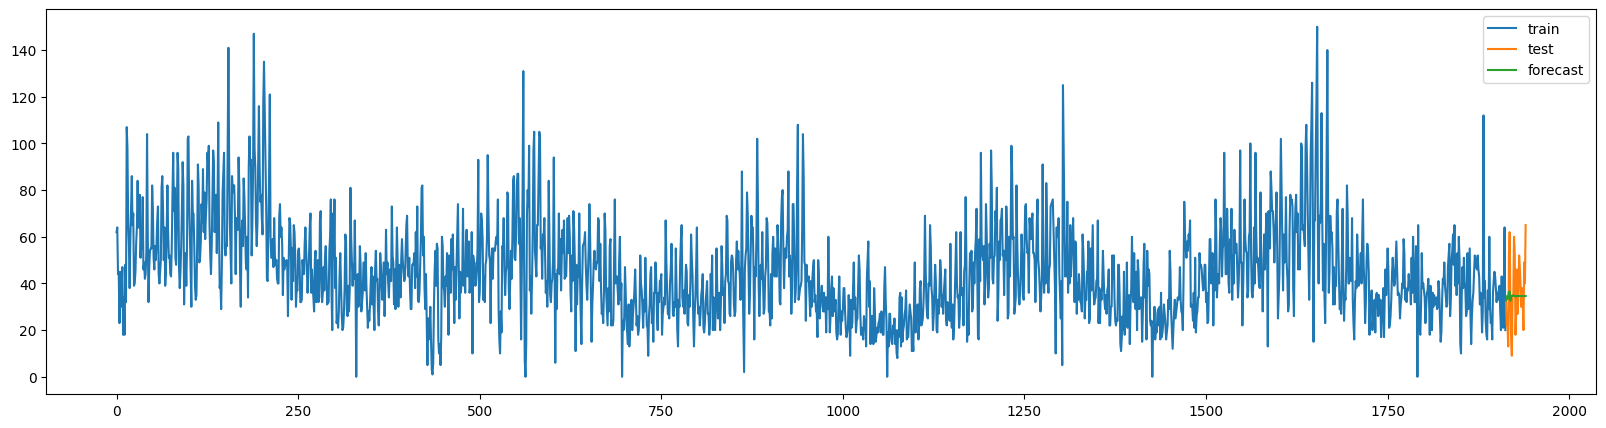

MAE: 11.771114647371514
RMSE: 14.648576863905028


In [21]:
forecast_seasonal_rma = pd.Series(index=test_seasonal.index, dtype=float)
window_seasonal = list(train_seasonal[-7:])
for i in range(len(test_seasonal)):
    forecast_seasonal_rma.iloc[i] = np.mean(window_seasonal[-7:])
    window_seasonal.append(forecast_seasonal_rma.iloc[i])

mae_seasonal_rma, rmse_seasonal_rma = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_rma)

# ETS

In [22]:
def ets_grid_search(train):
  errors = ["add", "mul"]
  trends = [None, "add", "mul"]
  damped_trends = [False, True]  # only applicable if trend is there
  seasonals = [None, "add", "mul"]
  seasonal_periods = 7  # only applicable is seasonal is there

  results = []
  failed_models = []

  for error in errors:
    for trend in trends:
      for damped_trend in damped_trends:
        for seasonal in seasonals:
          if trend is None and damped_trend:
            continue
          model_name = f"ETS({error}, {trend}, {seasonal}), damped = {damped_trend}"
          try:
            model = ETSModel(train, error=error, trend=trend, damped_trend=damped_trend, seasonal=seasonal, seasonal_periods=seasonal_periods if seasonal else None)
            fit = model.fit()
            results.append({"model" : model_name, "BIC" : fit.bic})
          except Exception as e:
            failed_models.append({"model" : model_name, "error" : str(e)})

  results_df = pd.DataFrame(results)
  results_df = results_df.sort_values(by=["BIC"])
  print(results_df)
  best_model = results_df.iloc[0]
  print(f"\nBest model = {best_model['model']}, BIC : {best_model['BIC']:.4f}")
  if failed_models:
    print(f"\nFailed models ({len(failed_models)}):")
    print(pd.DataFrame(failed_models))

In [23]:
ets_grid_search(train_stable)

                                  model           BIC
1   ETS(add, None, add), damped = False  14149.569048
5     ETS(add, add, add), damped = True  14172.318132
3    ETS(add, add, add), damped = False  14183.465750
0  ETS(add, None, None), damped = False  14219.136232
2   ETS(add, add, None), damped = False  14234.024460
4    ETS(add, add, None), damped = True  14241.658943

Best model = ETS(add, None, add), damped = False, BIC : 14149.5690

Failed models (24):
                                   model  \
0    ETS(add, None, mul), damped = False   
1     ETS(add, add, mul), damped = False   
2      ETS(add, add, mul), damped = True   
3    ETS(add, mul, None), damped = False   
4     ETS(add, mul, add), damped = False   
5     ETS(add, mul, mul), damped = False   
6     ETS(add, mul, None), damped = True   
7      ETS(add, mul, add), damped = True   
8      ETS(add, mul, mul), damped = True   
9   ETS(mul, None, None), damped = False   
10   ETS(mul, None, add), damped = False   
11   

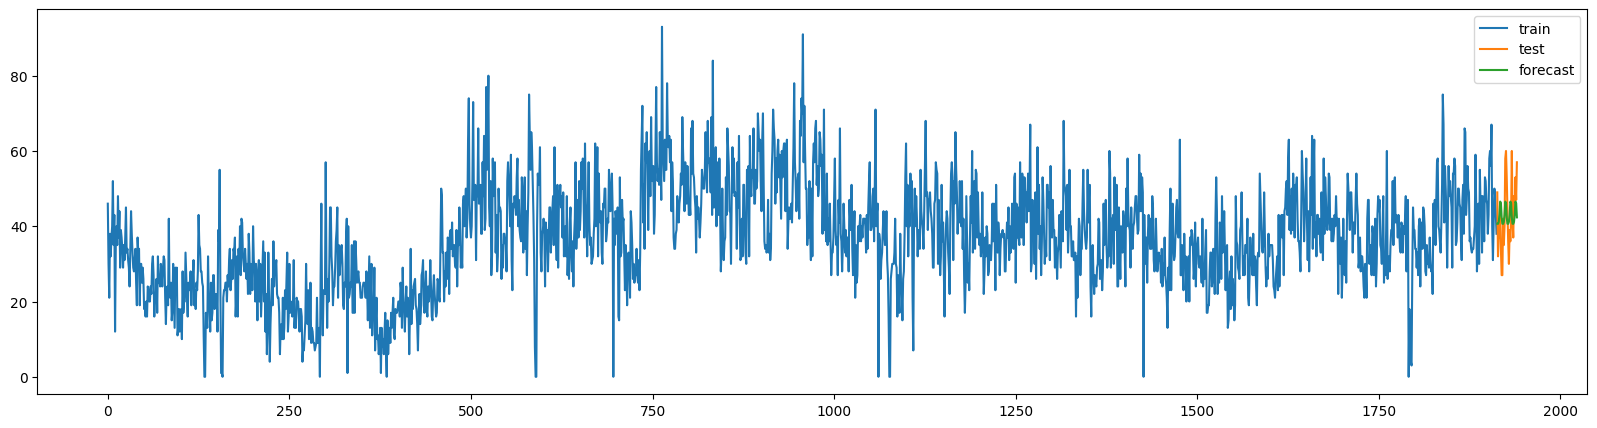

MAE: 7.309862410906815
RMSE: 8.823412853281802


In [24]:
final_model_stable = ETSModel(train_stable, error="add", trend=None, damped_trend=False, seasonal="add", seasonal_periods=7)
fit_stable_ets = final_model_stable.fit()
forecast_stable_ets = fit_stable_ets.forecast(len(test_stable))
forecast_stable_ets.index = test_stable.index

mae_stable_ets, rmse_stable_ets = evaluate_forecast(train_stable, test_stable, forecast_stable_ets)

In [25]:
ets_grid_search(train_sporadic)

                                  model          BIC
0  ETS(add, None, None), damped = False  4749.081006
2   ETS(add, add, None), damped = False  4764.384049
4    ETS(add, add, None), damped = True  4771.780925
1   ETS(add, None, add), damped = False  4778.573291
3    ETS(add, add, add), damped = False  4793.876656
5     ETS(add, add, add), damped = True  4801.263986

Best model = ETS(add, None, None), damped = False, BIC : 4749.0810

Failed models (24):
                                   model  \
0    ETS(add, None, mul), damped = False   
1     ETS(add, add, mul), damped = False   
2      ETS(add, add, mul), damped = True   
3    ETS(add, mul, None), damped = False   
4     ETS(add, mul, add), damped = False   
5     ETS(add, mul, mul), damped = False   
6     ETS(add, mul, None), damped = True   
7      ETS(add, mul, add), damped = True   
8      ETS(add, mul, mul), damped = True   
9   ETS(mul, None, None), damped = False   
10   ETS(mul, None, add), damped = False   
11   ETS(mul

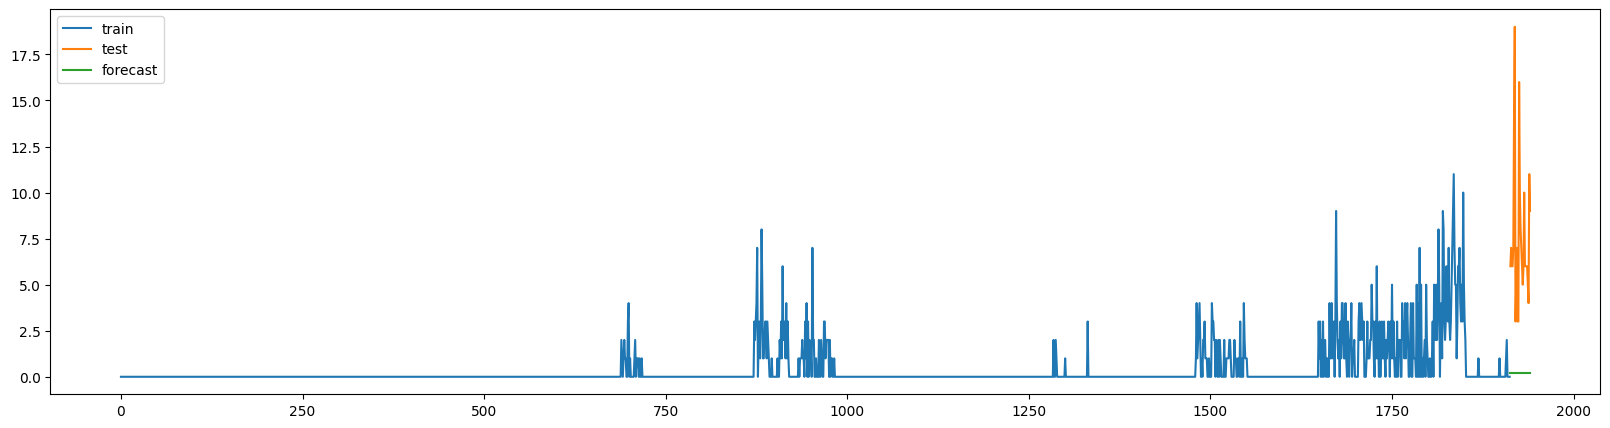

MAE: 7.163068361134557
RMSE: 8.069665254883796


In [26]:
final_model_sporadic = ETSModel(train_sporadic, error="add", trend=None, damped_trend=False, seasonal=None, seasonal_periods=None)
fit_sporadic_ets = final_model_sporadic.fit()
forecast_sporadic_ets = fit_sporadic_ets.forecast(len(test_sporadic))
forecast_sporadic_ets.index = test_sporadic.index

mae_sporadic_ets, rmse_sporadic_ets = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_ets)

In [27]:
ets_grid_search(train_seasonal)

                                  model           BIC
1   ETS(add, None, add), damped = False  15639.446101
3    ETS(add, add, add), damped = False  15654.730994
5     ETS(add, add, add), damped = True  15660.513617
0  ETS(add, None, None), damped = False  16311.456618
2   ETS(add, add, None), damped = False  16329.220019
4    ETS(add, add, None), damped = True  16334.948673

Best model = ETS(add, None, add), damped = False, BIC : 15639.4461

Failed models (24):
                                   model  \
0    ETS(add, None, mul), damped = False   
1     ETS(add, add, mul), damped = False   
2      ETS(add, add, mul), damped = True   
3    ETS(add, mul, None), damped = False   
4     ETS(add, mul, add), damped = False   
5     ETS(add, mul, mul), damped = False   
6     ETS(add, mul, None), damped = True   
7      ETS(add, mul, add), damped = True   
8      ETS(add, mul, mul), damped = True   
9   ETS(mul, None, None), damped = False   
10   ETS(mul, None, add), damped = False   
11   

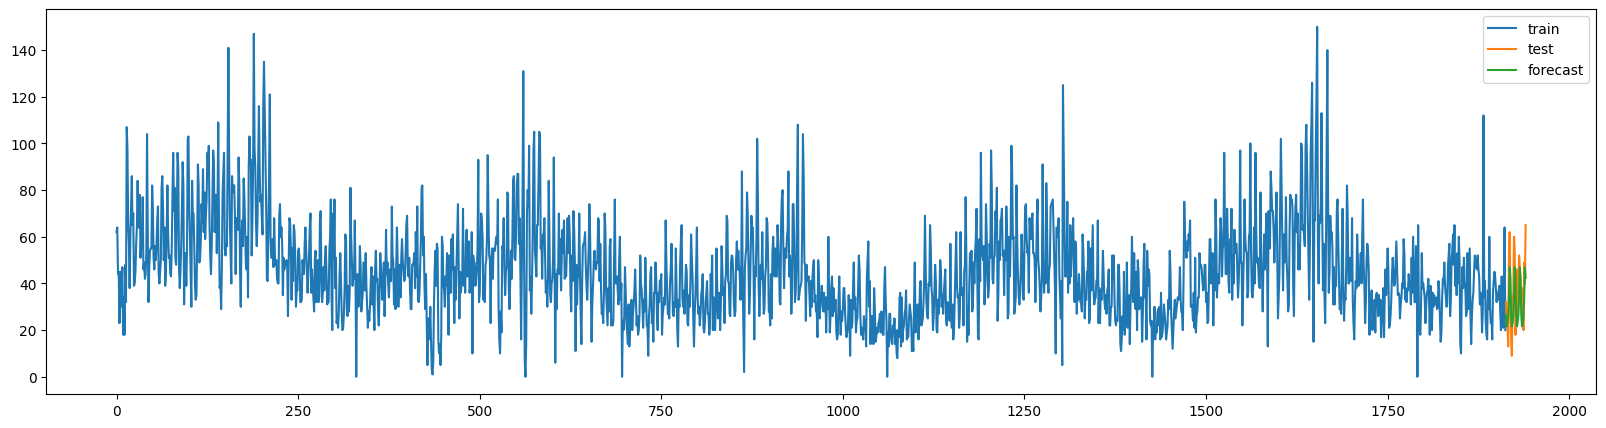

MAE: 10.844574249727605
RMSE: 13.22490863770078


In [28]:
final_model_seasonal = ETSModel(train_seasonal, error="add", trend=None, damped_trend=False, seasonal="add", seasonal_periods=7)
fit_seasonal_ets = final_model_seasonal.fit()
forecast_seasonal_ets = fit_seasonal_ets.forecast(len(test_seasonal))
forecast_seasonal_ets.index = test_seasonal.index

mae_seasonal_ets, rmse_seasonal_ets = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_ets)

# ARIMA

In [29]:
def adf(series):
  adf_result = adfuller(series.dropna())
  print(f"test statistic = {adf_result[0]:.4f}")
  print(f"p value = {adf_result[1]:.4f}")
  print("no of lags =", adf_result[2])
  print("no of observations =", adf_result[3])
  print("critical values at:")
  print(f"1% : {adf_result[4]['1%']:.4f}")
  print(f"5% : {adf_result[4]['5%']:.4f}")
  print(f"10% : {adf_result[4]['10%']:.4f}")

def kpss_c(series):  # series is stationary around a constant (level stationary)
  kpss_c_result = kpss(series.dropna(), regression='c')
  print(f"test statistic = {kpss_c_result[0]:.4f}")
  print(f"p value = {kpss_c_result[1]:.4f}")
  print("no of lags =", kpss_c_result[2])
  print("critical values at:")
  print(f"10% : {kpss_c_result[3]['10%']:.4f}")
  print(f"5% : {kpss_c_result[3]['5%']:.4f}")
  print(f"2.5% : {kpss_c_result[3]['2.5%']:.4f}")
  print(f"1% : {kpss_c_result[3]['1%']:.4f}")

def kpss_ct(series):  # series is stationary around a deterministic trend (trend stationary)
  kpss_ct_result = kpss(series.dropna(), regression='ct')
  print(f"test statistic = {kpss_ct_result[0]:.4f}")
  print(f"p value = {kpss_ct_result[1]:.4f}")
  print("no of lags =", kpss_ct_result[2])
  print("critical values at:")
  print(f"10% : {kpss_ct_result[3]['10%']:.4f}")
  print(f"5% : {kpss_ct_result[3]['5%']:.4f}")
  print(f"2.5% : {kpss_ct_result[3]['2.5%']:.4f}")
  print(f"1% : {kpss_ct_result[3]['1%']:.4f}")

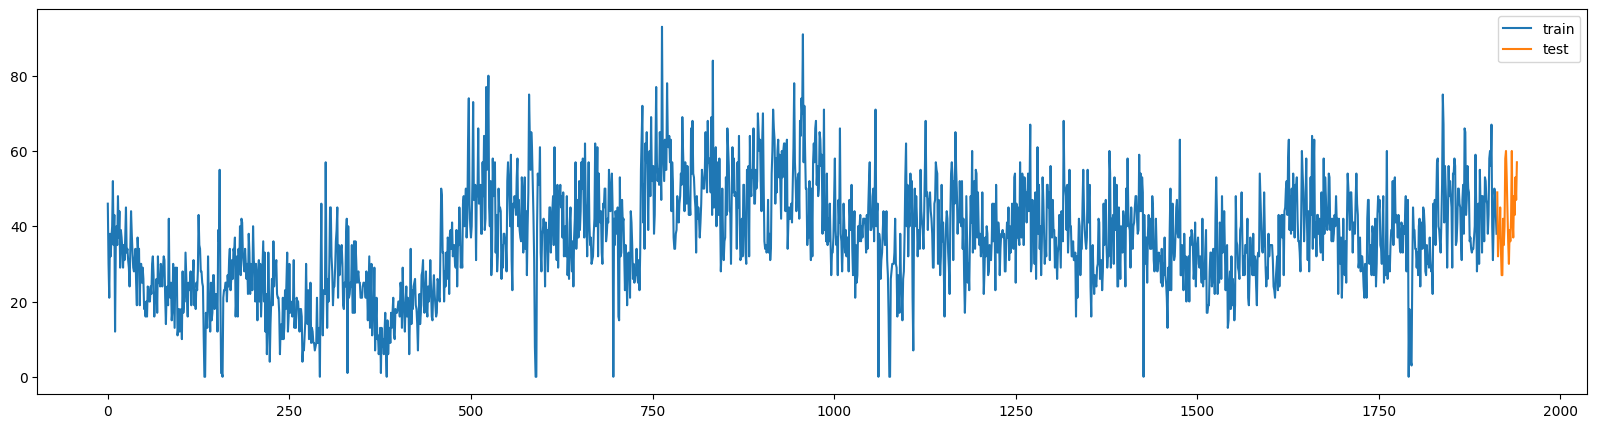

In [30]:
plt.figure(figsize=(20, 5))
train_stable.plot(label='train')
test_stable.plot(label='test')
plt.legend()
plt.show()

In [31]:
adf(train_stable)
kpss_c(train_stable)
kpss_ct(train_stable)

test statistic = -2.8675
p value = 0.0493
no of lags = 26
no of observations = 1886
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 1.7580
p value = 0.0100
no of lags = 25
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.8271
p value = 0.0100
no of lags = 25
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


Both first-order differencing and seasonal differencing (lag=7) passed the stationary tests. Hence ACF and PACF plots were examined for the original, first-differenced and seasonally differenced series.

The first-differenced series showed the most consistent stationarity behaviour with minimal seasonal spikes in the ACF/PACF plots compared to the other transformations. Based on this, first-order differencing was selected for model building.

This suggests that the series exhibits weak seasonality and that most of the non-stationarity is driven by trend rather than seasonal structure.

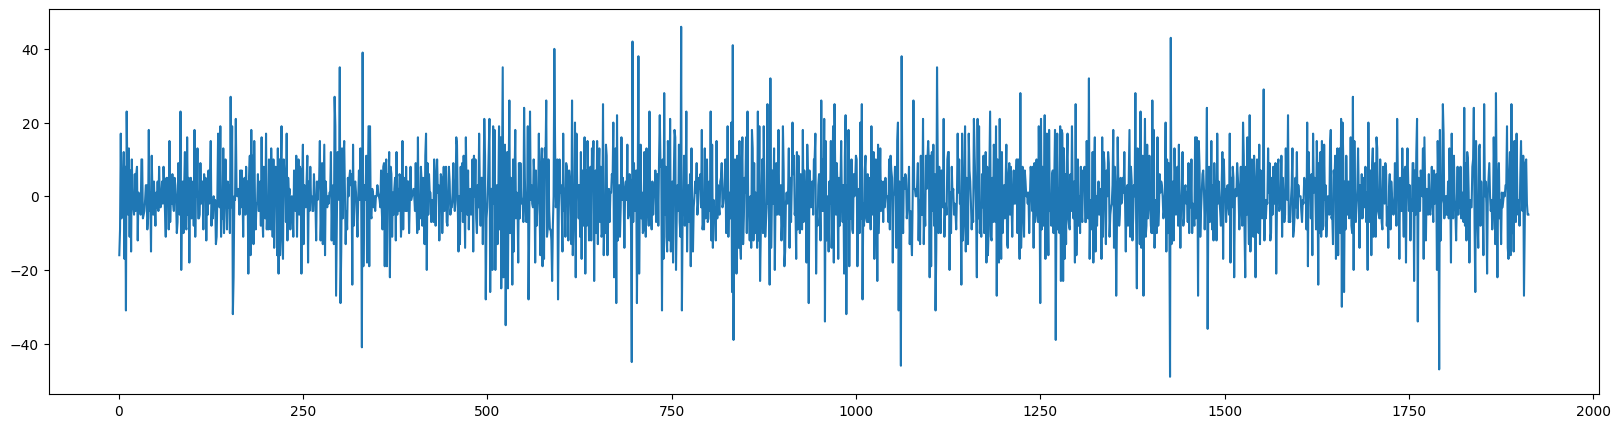

In [32]:
train_stable_diff = train_stable.diff()

plt.figure(figsize=(20, 5))
train_stable_diff.plot()
plt.show()

In [33]:
adf(train_stable_diff)
kpss_c(train_stable_diff)
kpss_ct(train_stable_diff)

test statistic = -14.4778
p value = 0.0000
no of lags = 26
no of observations = 1885
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 0.0540
p value = 0.1000
no of lags = 124
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.0535
p value = 0.1000
no of lags = 124
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


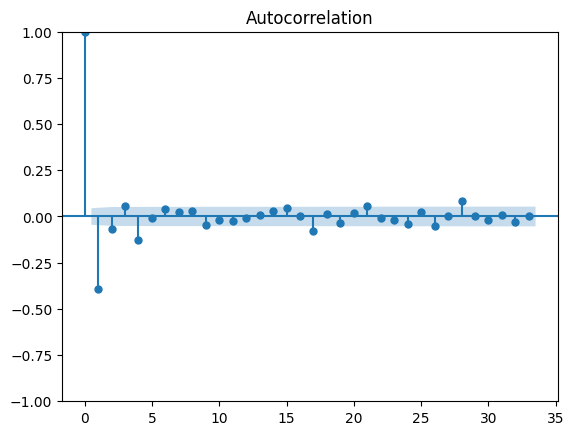

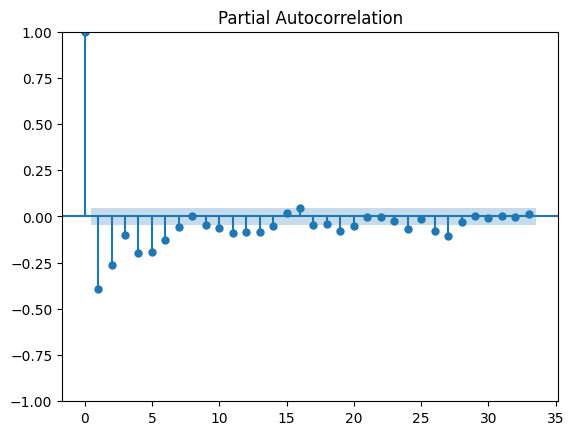

In [34]:
plot_acf(train_stable_diff.dropna())
plt.show()
plot_pacf(train_stable_diff.dropna())
plt.show()

In [35]:
def arima_grid_search(train, d):
  results = []
  failed_models = []
  for p in range(4):
    for q in range(4):
      try:
        model = ARIMA(train, order=(p, d, q))
        fit = model.fit()
        results.append((p, q, fit.bic))
      except Exception as e:
        failed_models.append({"model_order" : (p, d, q), "error" : str(e)})

  results_df = pd.DataFrame(results, columns=["p", "q", "BIC"])
  print(results_df.sort_values('BIC').head())
  if failed_models:
      print(f"\nFailed models ({len(failed_models)}):")
      print(pd.DataFrame(failed_models))

In [36]:
arima_grid_search(train_stable, d=1)

    p  q           BIC
15  3  3  14126.885645
6   1  2  14129.327408
9   2  1  14131.111540
5   1  1  14131.199937
14  3  2  14133.090567


In [37]:
model_stable = ARIMA(train_stable, order=(3, 1, 3))
fit_stable_arima = model_stable.fit()
print(fit_stable_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  26842   No. Observations:                 1913
Model:                 ARIMA(3, 1, 3)   Log Likelihood               -7036.997
Date:                Tue, 19 May 2026   AIC                          14087.994
Time:                        05:57:07   BIC                          14126.886
Sample:                             0   HQIC                         14102.307
                               - 1913                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4984      0.055      8.991      0.000       0.390       0.607
ar.L2         -0.8445      0.057    -14.823      0.000      -0.956      -0.733
ar.L3          0.2468      0.030      8.344      0.0

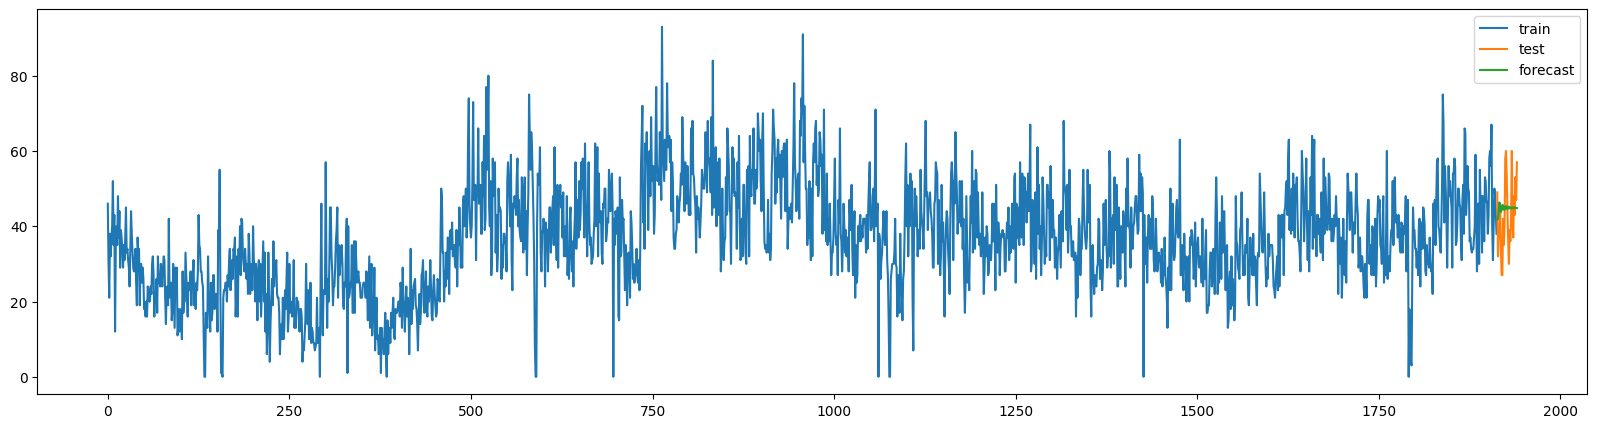

MAE: 8.112257555226327
RMSE: 9.525959886575832


In [38]:
forecast_stable_arima = fit_stable_arima.forecast(steps=len(test_stable))
forecast_stable_arima.index = test_stable.index

mae_stable_arima, rmse_stable_arima = evaluate_forecast(train_stable, test_stable, forecast_stable_arima)

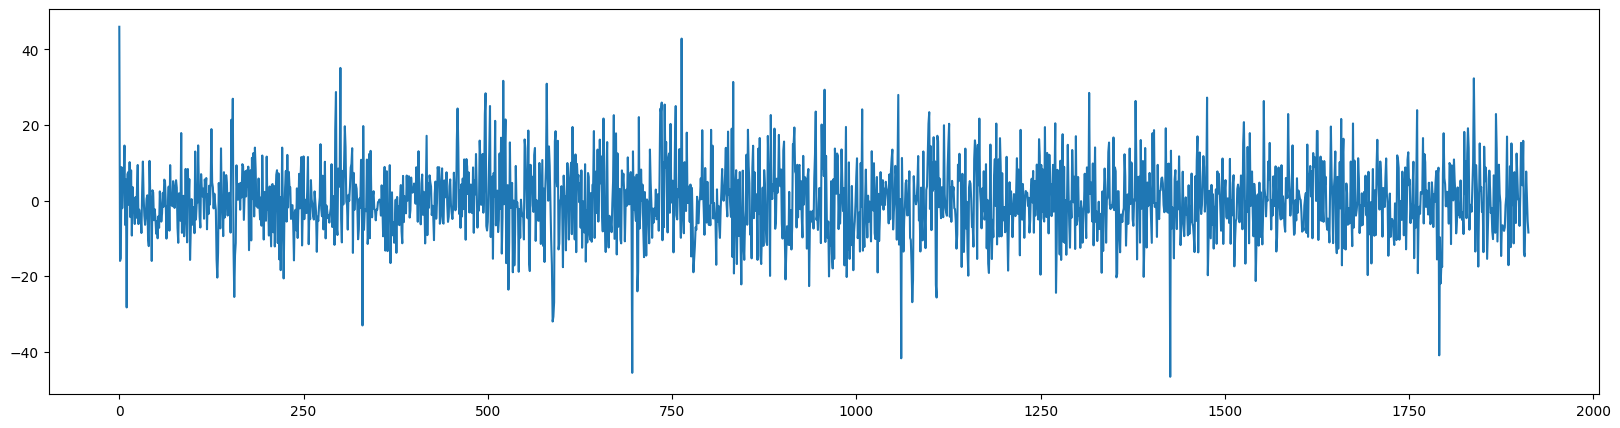

In [39]:
residuals_stable_arima = fit_stable_arima.resid

plt.figure(figsize=(20, 5))
residuals_stable_arima.plot()
plt.show()

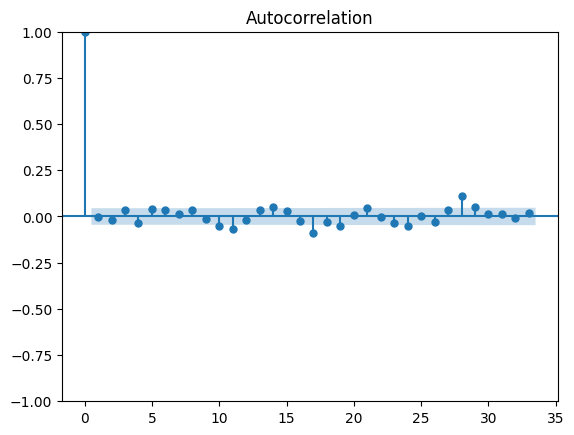

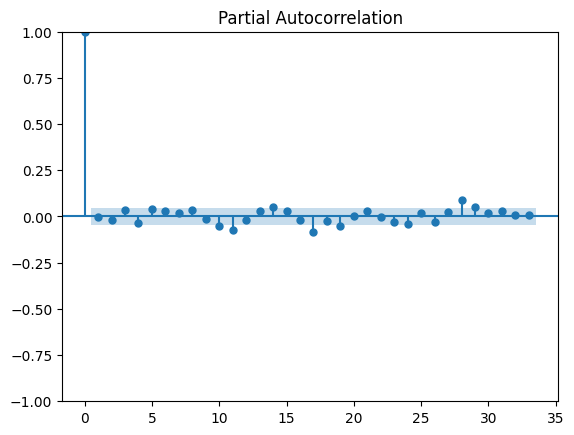

In [40]:
plot_acf(residuals_stable_arima.dropna())
plt.show()
plot_pacf(residuals_stable_arima.dropna())
plt.show()

Lag = 7 is used to test for remaining weekly dependence in residual structure, consistent with the known 7-day seasonal cycle in daily retail demand data.

Ljung-Box - mean structure

ARCH - variance structure

In [41]:
# model_df = p + q = 3 + 3
ljung_box_stable = acorr_ljungbox(residuals_stable_arima, lags=[7, 14, 28], model_df=6)  # Lags 7, 14, and 28 were selected to evaluate residual autocorrelation at weekly and multi-week seasonal horizons, consistent with the weekly periodicity observed in the data.
print(ljung_box_stable)

      lb_stat     lb_pvalue
7   11.074348  8.753020e-04
14  36.201315  1.613088e-05
28  99.657451  7.402927e-12


In [42]:
arch_test_stable = het_arch(residuals_stable_arima, nlags=7, ddof=6)  # testing weekly volatility clustering in residuals
print(f"LM statistic = {arch_test_stable[0]:.4f}")
print(f"LM p value = {arch_test_stable[1]:.4f}")
print(f"F statistic = {arch_test_stable[2]:.4f}")
print(f"F p value = {arch_test_stable[3]:.4f}")

LM statistic = 36.0834
LM p value = 0.0000
F statistic = 5.2490
F p value = 0.0000


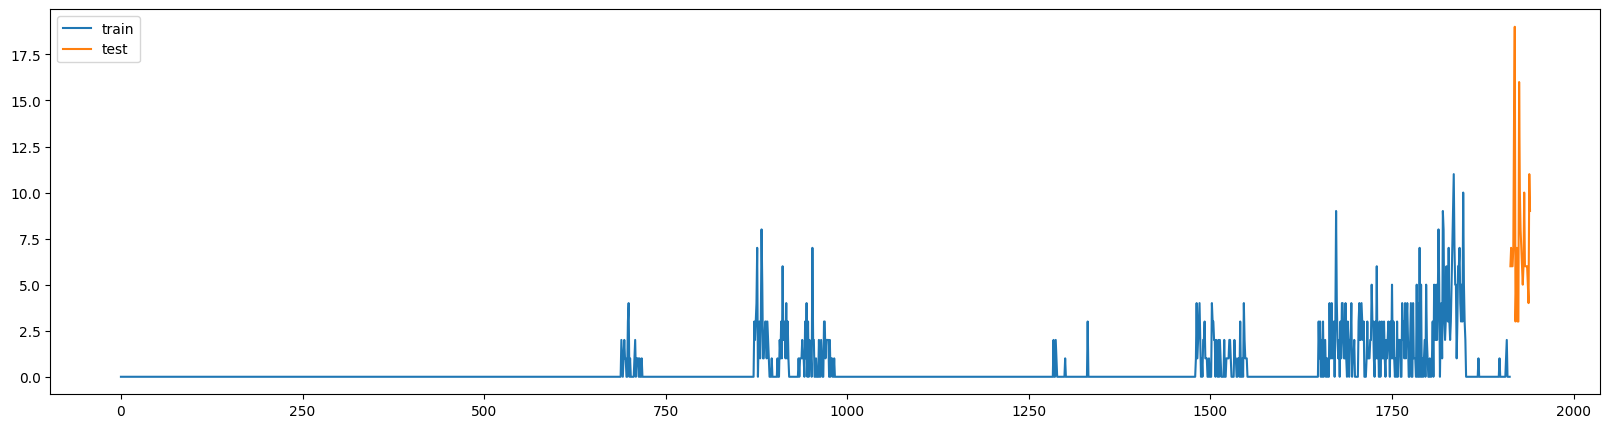

In [43]:
plt.figure(figsize=(20, 5))
train_sporadic.plot(label='train')
test_sporadic.plot(label='test')
plt.legend()
plt.show()

In [44]:
adf(train_sporadic)
kpss_c(train_sporadic)
kpss_ct(train_sporadic)

test statistic = -4.1932
p value = 0.0007
no of lags = 24
no of observations = 1888
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 1.8635
p value = 0.0100
no of lags = 25
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.3110
p value = 0.0100
no of lags = 25
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


Both first-order differencing and seasonal differencing (lag=7) passed the stationary tests. Hence ACF and PACF plots were examined for the original, first-differenced and seasonally differenced series.

The first-differenced series showed the most consistent stationarity behaviour with minimal seasonal spikes in the ACF/PACF plots compared to the other transformations. Based on this, first-order differencing was selected for model building.

This suggests that the series exhibits weak seasonality and that most of the non-stationarity is driven by trend rather than seasonal structure.

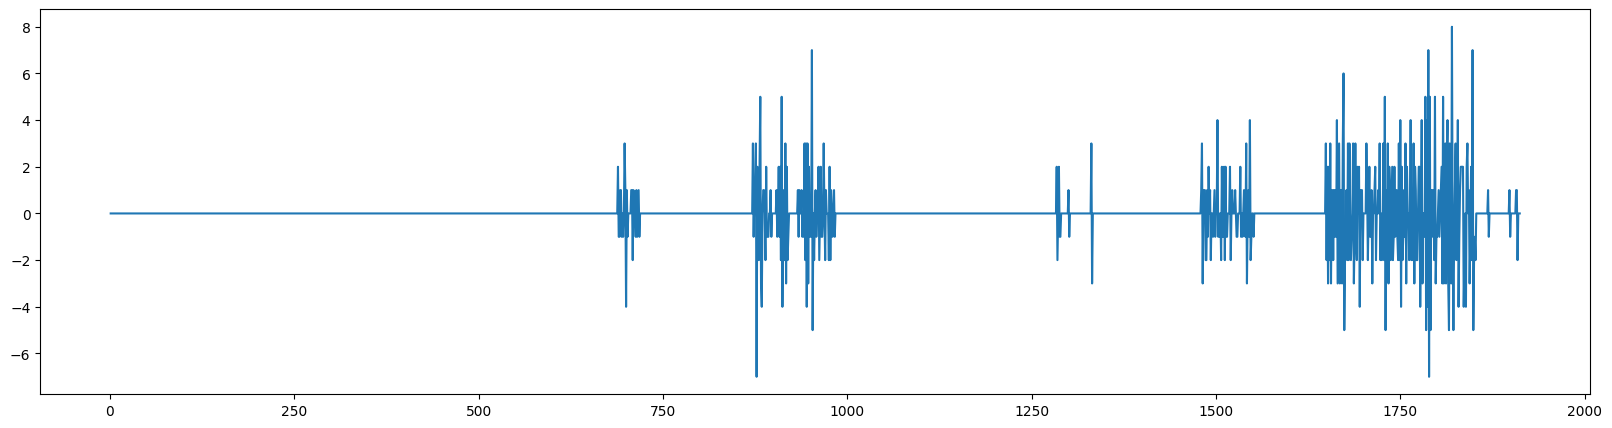

In [45]:
train_sporadic_diff = train_sporadic.diff()

plt.figure(figsize=(20, 5))
train_sporadic_diff.plot()
plt.show()

In [46]:
adf(train_sporadic_diff)
kpss_c(train_sporadic_diff)
kpss_ct(train_sporadic_diff)

test statistic = -11.9080
p value = 0.0000
no of lags = 23
no of observations = 1888
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 0.0312
p value = 0.1000
no of lags = 91
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.0304
p value = 0.1000
no of lags = 91
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


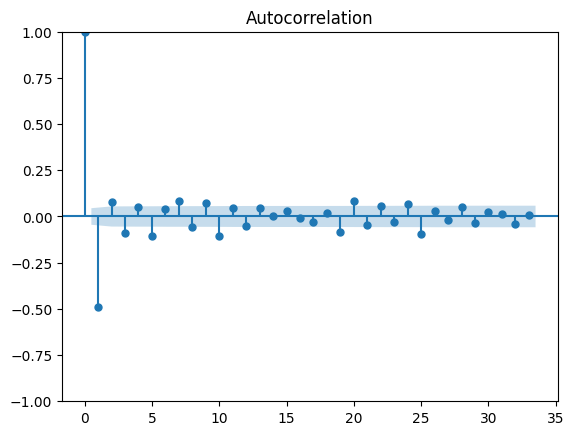

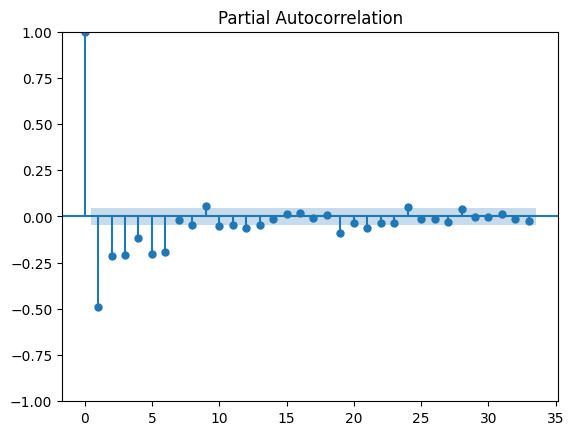

In [47]:
plot_acf(train_sporadic_diff.dropna())
plt.show()
plot_pacf(train_sporadic_diff.dropna())
plt.show()

In [48]:
arima_grid_search(train_sporadic, d=1)

    p  q          BIC
3   0  3  4734.788287
9   2  1  4736.289952
10  2  2  4739.021527
7   1  3  4739.745968
13  3  1  4739.938253


In [49]:
model_sporadic = ARIMA(train_sporadic, order=(0, 1, 3))
fit_sporadic_arima = model_sporadic.fit()
print(fit_sporadic_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                   5654   No. Observations:                 1913
Model:                 ARIMA(0, 1, 3)   Log Likelihood               -2352.282
Date:                Tue, 19 May 2026   AIC                           4712.565
Time:                        05:57:22   BIC                           4734.788
Sample:                             0   HQIC                          4720.743
                               - 1913                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7363      0.010    -72.253      0.000      -0.756      -0.716
ma.L2          0.0289      0.012      2.368      0.018       0.005       0.053
ma.L3         -0.0960      0.010     -9.626      0.0

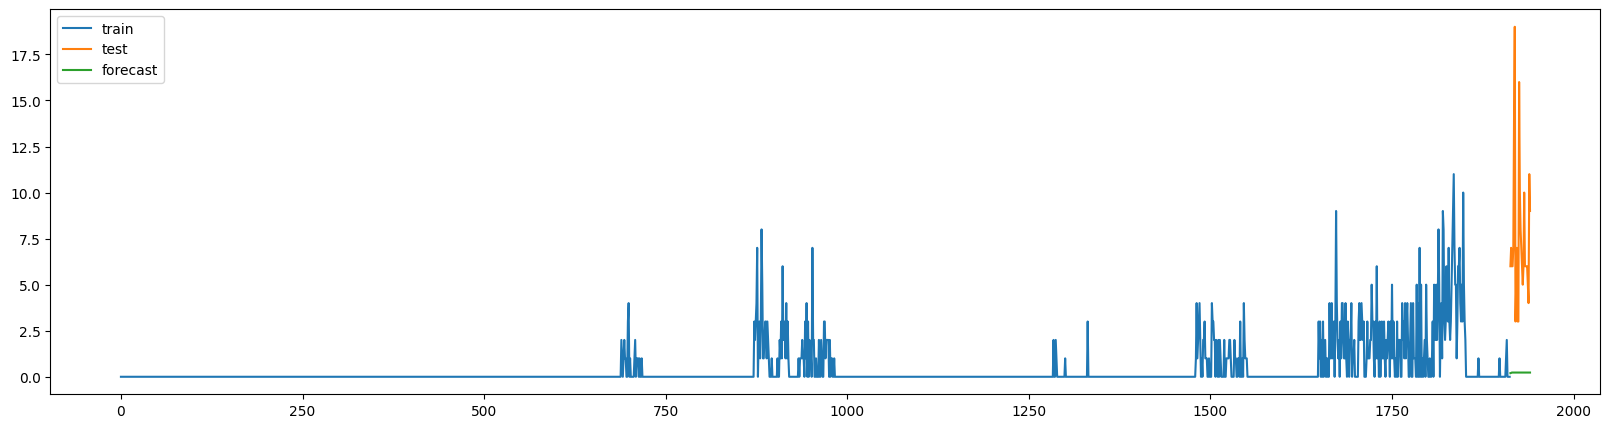

MAE: 7.16516078373625
RMSE: 8.071287534730622


In [50]:
forecast_sporadic_arima = fit_sporadic_arima.forecast(steps=len(test_sporadic))
forecast_sporadic_arima.index = test_sporadic.index

mae_sporadic_arima, rmse_sporadic_arima = evaluate_forecast(train_sporadic, test_sporadic, forecast_sporadic_arima)

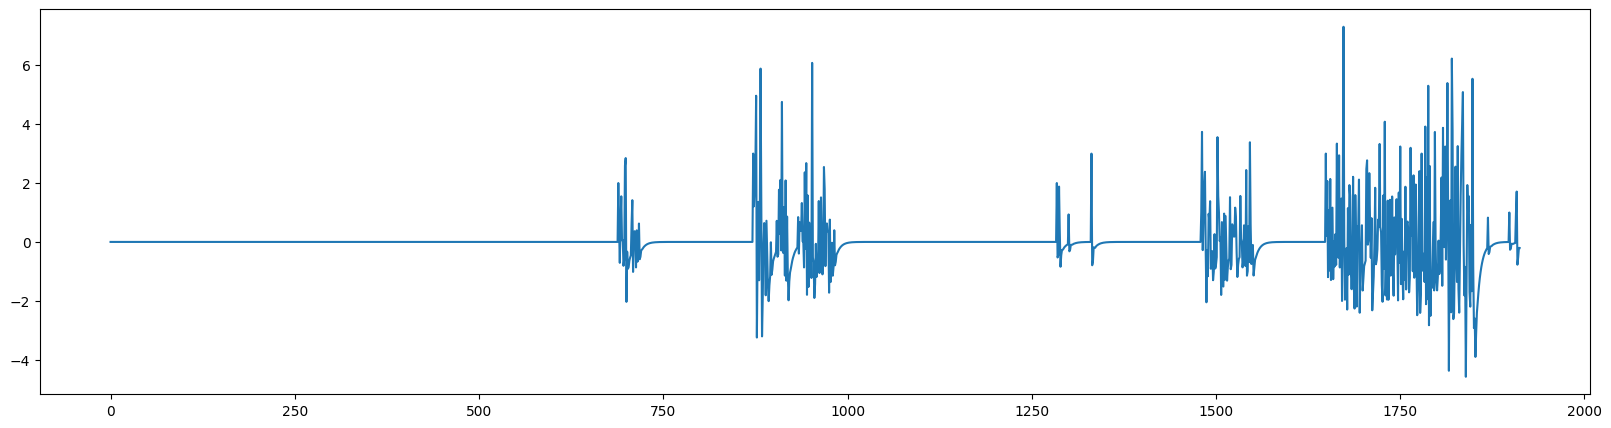

In [51]:
residuals_sporadic_arima = fit_sporadic_arima.resid

plt.figure(figsize=(20, 5))
residuals_sporadic_arima.plot()
plt.show()

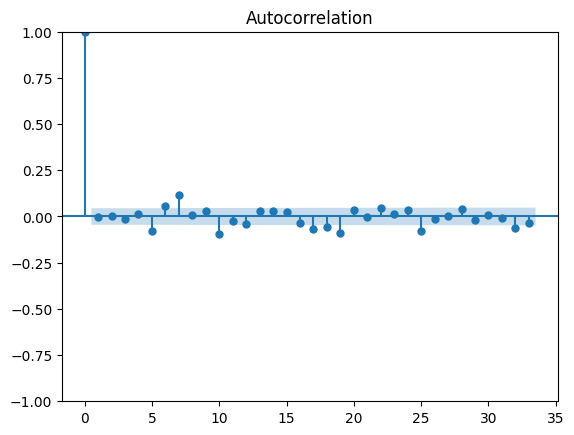

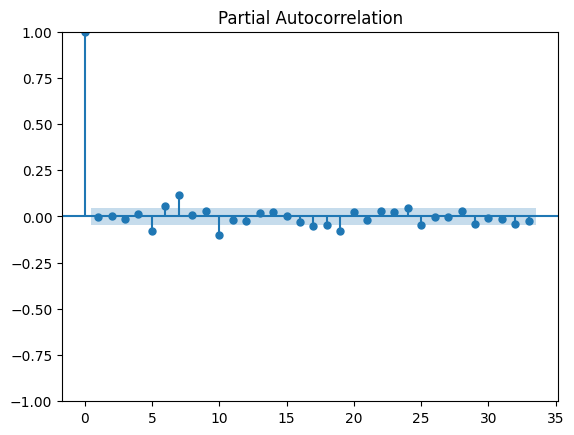

In [52]:
plot_acf(residuals_sporadic_arima.dropna())
plt.show()
plot_pacf(residuals_sporadic_arima.dropna())
plt.show()

In [53]:
# model_df = p + q = 0 + 3
ljung_box_sporadic = acorr_ljungbox(residuals_sporadic_arima, lags=[7, 14, 28], model_df=3)
print(ljung_box_sporadic)

       lb_stat     lb_pvalue
7    44.944384  4.083237e-09
14   71.769475  5.623863e-11
28  128.618312  6.511108e-16


In [54]:
arch_test_sporadic = het_arch(residuals_sporadic_arima, nlags=7, ddof=3)
print(f"LM statistic = {arch_test_sporadic[0]:.4f}")
print(f"LM p value = {arch_test_sporadic[1]:.4f}")
print(f"F statistic = {arch_test_sporadic[2]:.4f}")
print(f"F p value = {arch_test_sporadic[3]:.4f}")

LM statistic = 324.6846
LM p value = 0.0000
F statistic = 55.7784
F p value = 0.0000


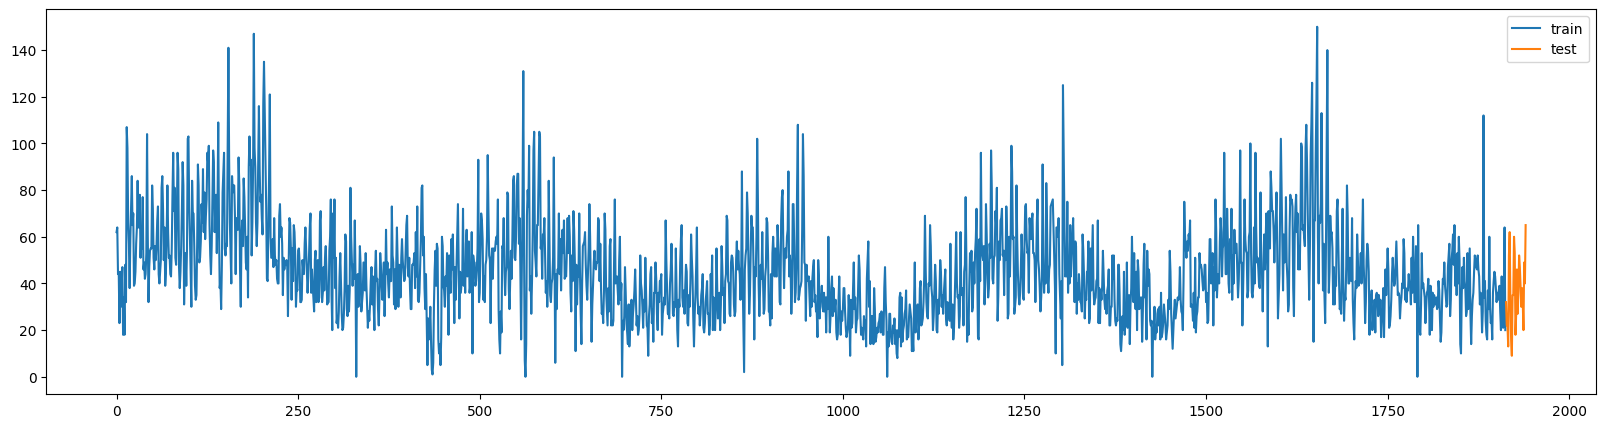

In [55]:
plt.figure(figsize=(20, 5))
train_seasonal.plot(label='train')
test_seasonal.plot(label='test')
plt.legend()
plt.show()

In [56]:
adf(train_seasonal)
kpss_c(train_seasonal)
kpss_ct(train_seasonal)

test statistic = -3.2870
p value = 0.0155
no of lags = 26
no of observations = 1886
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 1.1442
p value = 0.0100
no of lags = 21
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.5006
p value = 0.0100
no of lags = 21
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


Both first-order differencing, seasonal differencing (lag = 7), and seasonal differencing applied after first-order differencing passed the stationarity tests. Hence, ACF and PACF plots were examined for the original, first-differenced, seasonally differenced, and combined differenced (first-order + seasonal) series.

Both the seasonally differenced series and the combined differenced series showed improved stationarity behaviour, with reduced seasonal structure in the ACF plots compared to the other transformations. However, both still exhibited residual seasonal spikes in the PACF plots. The combined differenced series additionally showed a strong negative spike at lag 1 in the ACF, indicating signs of over-differencing.

Based on these observations, seasonal differencing (lag = 7) was selected for model building as it achieved stationarity without introducing over-differencing effects.

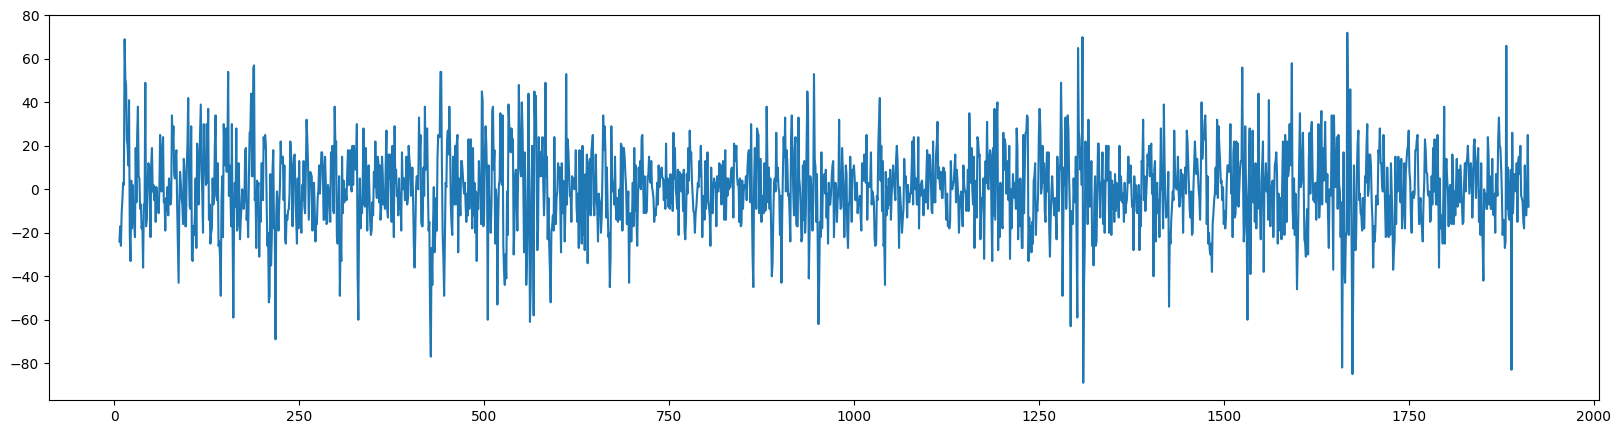

In [57]:
train_seasonal_se = train_seasonal - train_seasonal.shift(7)

plt.figure(figsize=(20, 5))
train_seasonal_se.plot()
plt.show()

In [58]:
adf(train_seasonal_se)
kpss_c(train_seasonal_se)
kpss_ct(train_seasonal_se)

test statistic = -11.2905
p value = 0.0000
no of lags = 22
no of observations = 1883
critical values at:
1% : -3.4338
5% : -2.8631
10% : -2.5676
test statistic = 0.0123
p value = 0.1000
no of lags = 8
critical values at:
10% : 0.3470
5% : 0.4630
2.5% : 0.5740
1% : 0.7390
test statistic = 0.0118
p value = 0.1000
no of lags = 8
critical values at:
10% : 0.1190
5% : 0.1460
2.5% : 0.1760
1% : 0.2160


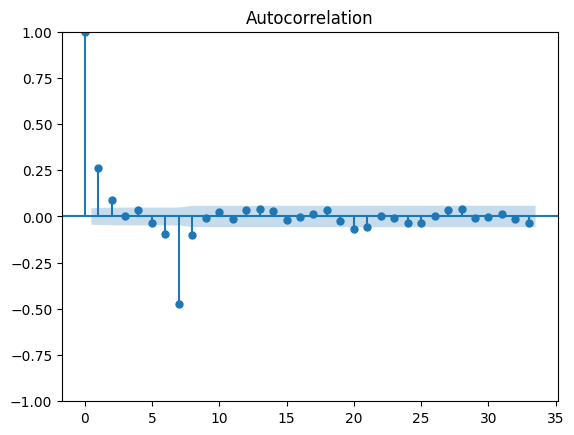

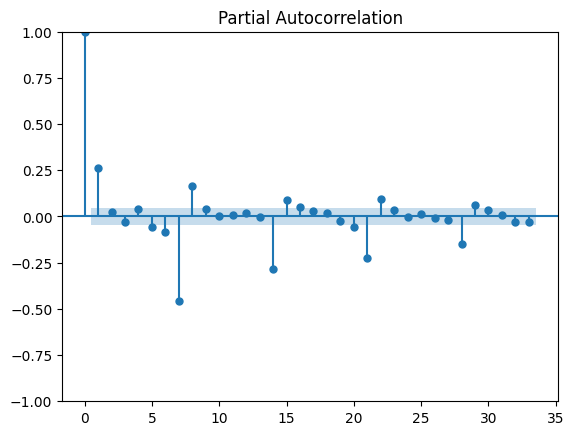

In [59]:
plot_acf(train_seasonal_se.dropna())
plt.show()
plot_pacf(train_seasonal_se.dropna())
plt.show()

In [60]:
def sarima_grid_search(train, d, D, s):
  results = []
  failed_models = []
  # to reduce complexity of grid search
  p = q = range(3)
  P = Q = range(2)
  pdq = list(itertools.product(p, [d], q))
  seasonal_pdq = list(itertools.product(P, [D], Q, [s]))
  for order in pdq:
    for seasonal_order in seasonal_pdq:
      try:
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
        fit = model.fit()
        results.append((order, seasonal_order, fit.bic))
      except Exception as e:
        failed_models.append({"model_order" : order, "model_seasonal_order" : seasonal_order, "error" : str(e)})

  results_df = pd.DataFrame(results, columns=["order", "seasonal_order", "BIC"])
  print(results_df.sort_values('BIC').head())
  if failed_models:
      print(f"\nFailed models ({len(failed_models)}):")
      print(pd.DataFrame(failed_models))

In [61]:
sarima_grid_search(train_seasonal, d = 0, D = 1, s = 7)

        order seasonal_order           BIC
31  (2, 0, 1)   (1, 1, 1, 7)  15443.497188
29  (2, 0, 1)   (0, 1, 1, 7)  15445.816841
35  (2, 0, 2)   (1, 1, 1, 7)  15451.990228
33  (2, 0, 2)   (0, 1, 1, 7)  15452.825195
23  (1, 0, 2)   (1, 1, 1, 7)  15453.694728


In [62]:
model_seasonal = SARIMAX(train_seasonal, order=(2, 0, 1), seasonal_order=(1, 1, 1, 7))
fit_seasonal_arima = model_seasonal.fit()
print(fit_seasonal_arima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             20770   No. Observations:                 1913
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -7699.090
Date:                           Tue, 19 May 2026   AIC                          15410.181
Time:                                   05:59:19   BIC                          15443.497
Sample:                                        0   HQIC                         15422.444
                                          - 1913                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2737      0.021     59.576      0.000       1.232       1.316
ar.L2         -0.2799      0.020    -13.774

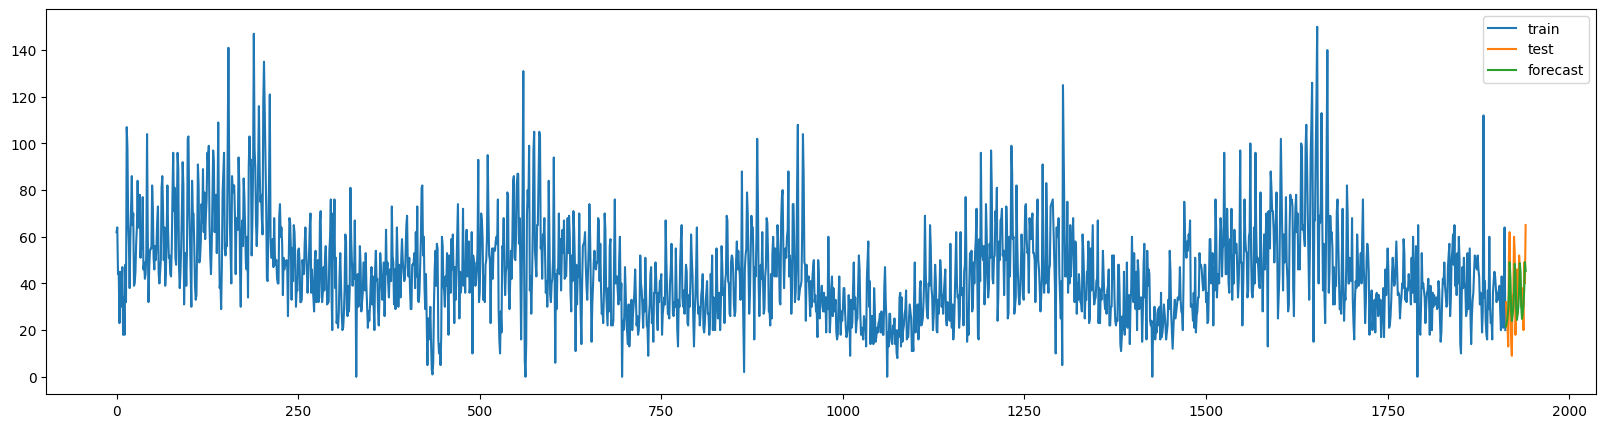

MAE: 10.231623205422007
RMSE: 12.416290795440597


In [63]:
forecast_seasonal_arima = fit_seasonal_arima.forecast(steps=len(test_seasonal))
forecast_seasonal_arima.index = test_seasonal.index

mae_seasonal_sarima, rmse_seasonal_sarima = evaluate_forecast(train_seasonal, test_seasonal, forecast_seasonal_arima)

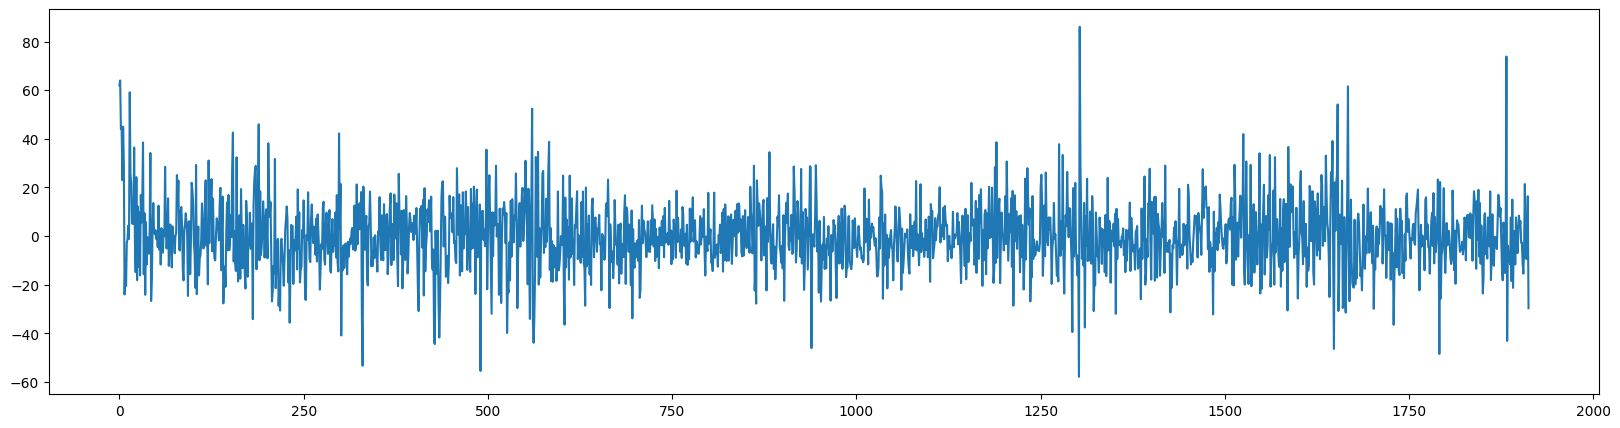

In [64]:
residuals_seasonal_arima = fit_seasonal_arima.resid

plt.figure(figsize=(20, 5))
residuals_seasonal_arima.plot()
plt.show()

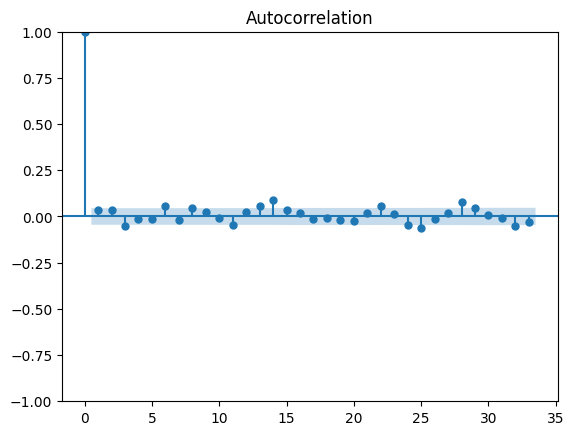

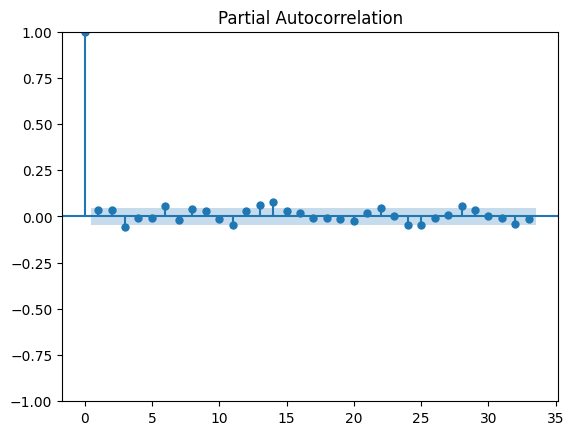

In [65]:
plot_acf(residuals_seasonal_arima.dropna())
plt.show()
plot_pacf(residuals_seasonal_arima.dropna())
plt.show()

In [66]:
# model_df = p + q + P + Q = 2 + 1 + 1 + 1
ljung_box_seasonal = acorr_ljungbox(residuals_seasonal_arima, lags=[7, 14, 28], model_df=5)
print(ljung_box_seasonal)

      lb_stat     lb_pvalue
7   17.339556  1.716972e-04
14  49.372589  1.413102e-07
28  85.948778  3.367516e-09


In [67]:
arch_test_seasonal = het_arch(residuals_seasonal_arima, nlags=7, ddof=5)
print(f"LM statistic = {arch_test_seasonal[0]:.4f}")
print(f"LM p value = {arch_test_seasonal[1]:.4f}")
print(f"F statistic = {arch_test_seasonal[2]:.4f}")
print(f"F p value = {arch_test_seasonal[3]:.4f}")

LM statistic = 114.7055
LM p value = 0.0000
F statistic = 17.4112
F p value = 0.0000


# Result summary

In [68]:
results_summary = pd.DataFrame([
    ["Stable", "Naive", mae_stable_naive, rmse_stable_naive],
    ["Stable", "Seasonal Naive", mae_stable_seasonal_naive, rmse_stable_seasonal_naive],
    ["Stable", "SMA", mae_stable_sma, rmse_stable_sma],
    ["Stable", "RMA", mae_stable_rma, rmse_stable_rma],
    ["Stable", "ETS", mae_stable_ets, rmse_stable_ets],
    ["Stable", "ARIMA", mae_stable_arima, rmse_stable_arima],

    ["Sporadic", "Naive", mae_sporadic_naive, rmse_sporadic_naive],
    ["Sporadic", "Seasonal Naive", mae_sporadic_seasonal_naive, rmse_sporadic_seasonal_naive],
    ["Sporadic", "SMA", mae_sporadic_sma, rmse_sporadic_sma],
    ["Sporadic", "RMA", mae_sporadic_rma, rmse_sporadic_rma],
    ["Sporadic", "ETS", mae_sporadic_ets, rmse_sporadic_ets],
    ["Sporadic", "ARIMA", mae_sporadic_arima, rmse_sporadic_arima],

    ["Seasonal", "Naive", mae_seasonal_naive, rmse_seasonal_naive],
    ["Seasonal", "Seasonal Naive", mae_seasonal_seasonal_naive, rmse_seasonal_seasonal_naive],
    ["Seasonal", "SMA", mae_seasonal_sma, rmse_seasonal_sma],
    ["Seasonal", "RMA", mae_seasonal_rma, rmse_seasonal_rma],
    ["Seasonal", "ETS", mae_seasonal_ets, rmse_seasonal_ets],
    ["Seasonal", "ARIMA", mae_seasonal_sarima, rmse_seasonal_sarima],
], columns=["Series", "Model", "MAE", "RMSE"])
print(results_summary)

      Series           Model        MAE       RMSE
0     Stable           Naive   8.035714  10.387149
1     Stable  Seasonal Naive   8.750000  10.248693
2     Stable             SMA   7.576531   9.409884
3     Stable             RMA   7.639608   9.354353
4     Stable             ETS   7.309862   8.823413
5     Stable           ARIMA   8.112258   9.525960
6   Sporadic           Naive   7.392857   8.274315
7   Sporadic  Seasonal Naive   6.964286   7.988831
8   Sporadic             SMA   6.964286   7.893746
9   Sporadic             RMA   7.095659   8.012948
10  Sporadic             ETS   7.163068   8.069665
11  Sporadic           ARIMA   7.165161   8.071288
12  Seasonal           Naive  17.785714  21.889332
13  Seasonal  Seasonal Naive  12.785714  16.250275
14  Seasonal             SMA  12.255102  15.235565
15  Seasonal             RMA  11.771115  14.648577
16  Seasonal             ETS  10.844574  13.224909
17  Seasonal           ARIMA  10.231623  12.416291


Stable -\
MAE = ETS\
RMSE = ETS

Sporadic -\
MAE = Seasonal Naive, SMA\
RMSE = SMA

Seasonal -\
MAE = ARIMA\
RMSE = ARIMA